# Biodiversity response variables — exploration

Built by `scripts/07_compute_taxonomic_beta_responses.R`. Phase 1 only — see
`README.md` ("Variables respuesta") for scope: taxonomic diversity (Hill numbers),
LCBD (Legendre & De Caceres 2013) and composition (PCoA). Phylogenetic diversity,
functional diversity and dark diversity are a separate, not-yet-implemented phase 2.

Unit of analysis: **one vegetation plot** (`PlotObservationID`), same 1,082-plot subset
as `notebooks/01_explore_phenology_db.ipynb`. Two abundance tiers, per the design
agreed in the README:

- **presence/absence** (`*_pa` columns) — all 1,082 plots, Jaccard dissimilarity.
- **cover-weighted** (`*_cover` columns) — only the `cover` stratum (~546 plots,
  `Cover` + `Cover_st`), Hellinger/Bray-Curtis. `NA` outside that stratum by
  design — no plot is ever dropped or imputed.

Composition axes are **PCoA**, not NMDS: with median richness = 5 species/plot, NMDS
(`vegan::metaMDS`) produced unstable solutions — plots with almost no shared species
got flung to absurd values on one axis by the iterative optimizer, a known NMDS
pathology at this level of sparsity. PCoA (`ape::pcoa`, Cailliez correction for the
negative eigenvalues that Jaccard/Bray produce) is a deterministic eigendecomposition
without that failure mode.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DERIVED = Path('../data/derived')

# Informal palette for exploration (not the paper's Okabe-Ito set in biodiv.figures --
# this notebook is not a source of figures for the manuscript).
BLUE, ORANGE, GREEN, RED, PURPLE = '#4C78A8', '#F58518', '#54A24B', '#E45756', '#B279A2'

resp = pd.read_parquet(DERIVED / 'biodiversity_responses.parquet')
plots = pd.read_parquet(DERIVED / 'plots_subset.parquet')
df = resp.merge(plots, on='PlotObservationID', how='left')

print('responses:', resp.shape)
print('merged   :', df.shape)
df.head()

responses: (1082, 12)
merged   : (1082, 30)


,PlotObservationID,hill_q0,hill_q1,hill_q2,lcbd_pa,p_lcbd_pa,pcoa1_pa,pcoa2_pa,lcbd_cover,p_lcbd_cover,...,lat,richness,n_records,stratum,Abundance_parameter,pixel_id,cell,win_start,win_end,win_years
0,32477,6.0,1.366220,1.145429,0.001058,0.001,0.137374,-0.144168,NaN,NaN,...,-30.65956,6,6,basal,Basal_area,8120_220169,49_1321,2001,2003,3
1,32479,4.0,1.428481,1.231409,0.001057,0.001,0.133980,-0.148337,NaN,NaN,...,-30.67519,4,4,basal,Basal_area,8121_220111,49_1321,2001,2003,3
2,32532,2.0,1.842709,1.725184,0.001070,0.001,0.156468,-0.104593,NaN,NaN,...,-37.80289,2,2,basal,Basal_area,4856_193614,29_1162,2010,2012,3
3,32644,25.0,9.656716,7.633149,0.001062,0.001,0.143443,-0.127482,0.002513,0.001,...,-37.82255,25,25,cover,Cover,4939_193545,30_1161,2004,2006,3
4,32645,31.0,8.621083,4.548669,0.001066,0.001,0.151469,-0.114513,0.002524,0.001,...,-37.82302,31,31,cover,Cover,4937_193543,30_1161,2004,2006,3


## 1. Taxonomic diversity (Hill numbers)

`hill_q0`, `hill_q1`, `hill_q2` are the same "effective number of species" family at
increasing sensitivity to abundance: q=0 is plain richness (should match the
`richness` column from `plots_subset.parquet` exactly), q=1 is the exponentiated
Shannon index, q=2 is the inverse Simpson index. The gap between q0 and q1 is an
evenness signal — a plot dominated by one species has q1 much lower than q0 even at
identical richness.

hill_q0 == richness: 100.0000% of plots (0 mismatches)


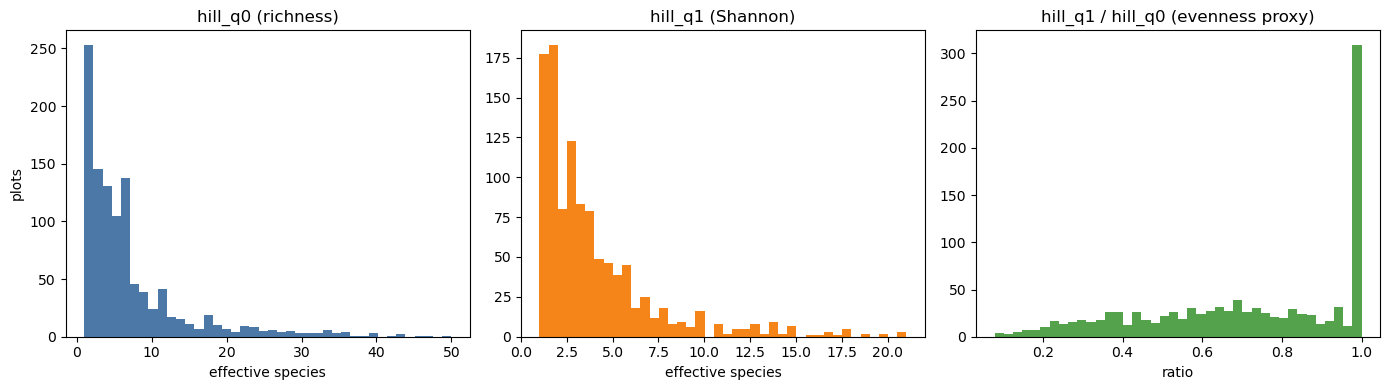

In [2]:
mismatch = (df['hill_q0'] - df['richness']).abs() > 1e-6
print(f"hill_q0 == richness: {(~mismatch).mean():.4%} of plots "
      f"({mismatch.sum()} mismatches)")

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].hist(df['hill_q0'], bins=40, color=BLUE)
ax[0].set(title='hill_q0 (richness)', xlabel='effective species', ylabel='plots')
ax[1].hist(df['hill_q1'], bins=40, color=ORANGE)
ax[1].set(title='hill_q1 (Shannon)', xlabel='effective species')
ax[2].hist(df['hill_q1'] / df['hill_q0'], bins=40, color=GREEN)
ax[2].set(title='hill_q1 / hill_q0 (evenness proxy)', xlabel='ratio')
fig.tight_layout()

## 2. Beta diversity (LCBD)

Local Contribution to Beta Diversity: how much each plot contributes to the total
compositional variance of the dataset — high LCBD marks compositionally unusual
plots, not species-rich ones (a species-poor but atypical plot can outscore a
species-rich, typical one). `p_lcbd_*` is the permutation-test p-value (999 perms) for
each plot's LCBD; `lcbd_pa`/`lcbd_cover` are computed on separate abundance tiers, so
they answer slightly different questions (compositional uniqueness by presence/absence
vs by relative cover) and need not agree for a given plot.

p_lcbd_pa: 274 / 1082 plots significant (p<0.05)
p_lcbd_cover: 81 / 546 plots significant (p<0.05)

corr(lcbd_pa, lcbd_cover) on the 546 plots with both = 0.902


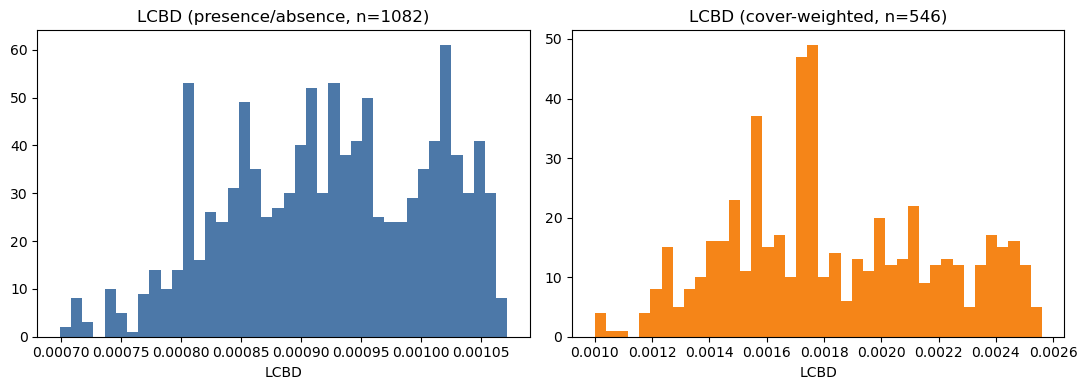

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(df['lcbd_pa'], bins=40, color=BLUE)
ax[0].set(title='LCBD (presence/absence, n=1082)', xlabel='LCBD')
ax[1].hist(df['lcbd_cover'].dropna(), bins=40, color=ORANGE)
ax[1].set(title='LCBD (cover-weighted, n=%d)' % df['lcbd_cover'].notna().sum(),
          xlabel='LCBD')
fig.tight_layout()

for col in ['p_lcbd_pa', 'p_lcbd_cover']:
    sig = df[col] < 0.05
    print(f"{col}: {sig.sum()} / {df[col].notna().sum()} plots significant (p<0.05)")

both = df.dropna(subset=['lcbd_pa', 'lcbd_cover'])
print(f"\ncorr(lcbd_pa, lcbd_cover) on the {len(both)} plots with both = "
      f"{both['lcbd_pa'].corr(both['lcbd_cover']):.3f}")

## 3. Composition (PCoA)

Two axes per tier. `%` variance explained is printed by the R script (check its log)
— PCoA is not rank-2 by construction the way a 2D NMDS solution is, so a low value
here is informative in a way NMDS stress is not: it says the two axes genuinely do not
capture much of the compositional variance, rather than saying the optimizer struggled.

Plots with almost no shared species can still dominate an eigenvector even without
NMDS's iterative instability. The same MAD-based rule the R script uses to flag
outliers is recomputed here to mark them on the scatter rather than silently plot
through them.

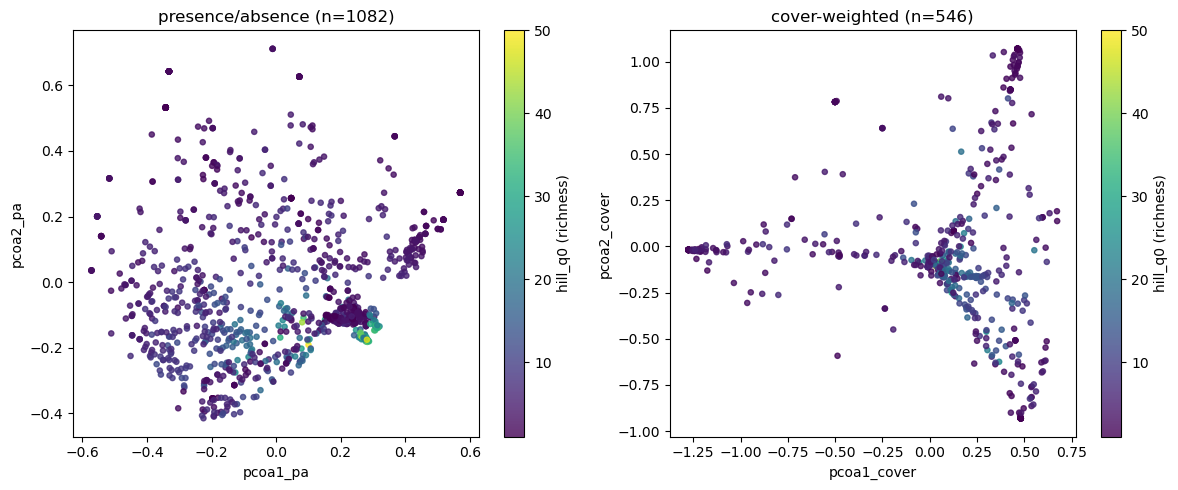

In [4]:
def mad_outliers(x, thresh=10.0):
    x = x.dropna()
    mad = (x - x.median()).abs().median() * 1.4826
    z = (x - x.median()).abs() / mad
    return x.index[z > thresh]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (x_col, y_col, title) in zip(axes, [
    ('pcoa1_pa', 'pcoa2_pa', 'presence/absence (n=1082)'),
    ('pcoa1_cover', 'pcoa2_cover', 'cover-weighted (n=%d)' % df['pcoa1_cover'].notna().sum()),
]):
    sub = df.dropna(subset=[x_col, y_col])
    outliers = mad_outliers(sub[x_col]).union(mad_outliers(sub[y_col]))
    ok = sub.index.difference(outliers)
    sc = ax.scatter(sub.loc[ok, x_col], sub.loc[ok, y_col],
                     c=sub.loc[ok, 'hill_q0'], cmap='viridis', s=14, alpha=0.8)
    if len(outliers):
        ax.scatter(sub.loc[outliers, x_col], sub.loc[outliers, y_col],
                    marker='x', color=RED, s=80, label='flagged outlier')
        for pid in outliers:
            print(f"[{title}] outlier: {df.loc[pid, 'PlotObservationID']}")
    ax.set(title=title, xlabel=x_col, ylabel=y_col)
    if len(outliers):
        ax.legend()
    fig.colorbar(sc, ax=ax, label='hill_q0 (richness)')
fig.tight_layout()

## 4. Two-tier coverage

`*_cover` columns exist only for the `cover` abundance stratum — everything else is
`NA` by design (never imputed, never dropped). Sanity-check the NA pattern against
`plots_subset.parquet`'s own `stratum` column before trusting the merge above.

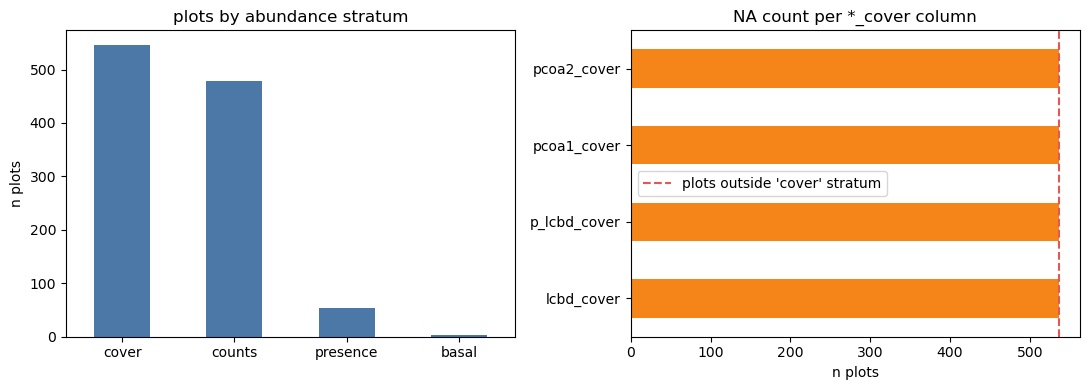

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
df['stratum'].value_counts().plot(kind='bar', ax=ax[0], color=BLUE)
ax[0].set(title='plots by abundance stratum', ylabel='n plots')
ax[0].tick_params(axis='x', rotation=0)

cover_cols = [c for c in df.columns if c.endswith('_cover')]
na_counts = df[cover_cols].isna().sum()
na_counts.plot(kind='barh', ax=ax[1], color=ORANGE)
ax[1].axvline((df['stratum'] != 'cover').sum(), color=RED, ls='--',
              label="plots outside 'cover' stratum")
ax[1].set(title='NA count per *_cover column', xlabel='n plots')
ax[1].legend()
fig.tight_layout()

## 5. Spatial pattern

Quick look at whether LCBD or richness cluster geographically before anyone treats
them as i.i.d. targets for cross-validation (they should not be — see
`src/biodiv/cv_groups.py` and the README's "Validacion" note on mandatory spatial
block CV).

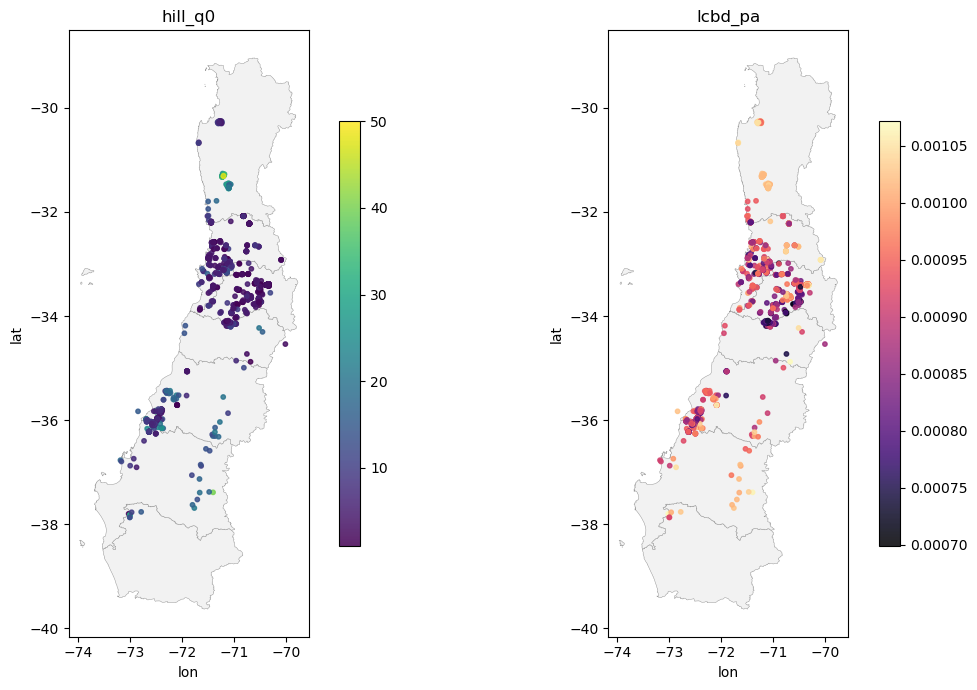

In [6]:
import geopandas as gpd

chile = gpd.read_file('../shapefiles/regiones_chile.shp')
chile = chile.to_crs('EPSG:4326')
chile = chile.cx[-73.5:-69.5, -38:-30]

fig, ax = plt.subplots(1, 2, figsize=(12, 7))
for a, col, cmap in zip(ax, ['hill_q0', 'lcbd_pa'], ['viridis', 'magma']):
    chile.plot(ax=a, facecolor='#F2F2F2', edgecolor='#9A9A9A', linewidth=0.35)
    sc = a.scatter(df['lon'], df['lat'], c=df[col], cmap=cmap, s=10, alpha=0.85)
    a.set(title=col, xlabel='lon', ylabel='lat', aspect='equal')
    fig.colorbar(sc, ax=a, shrink=0.7)
fig.tight_layout()

## 6. Any signal against predictors? (quick check before modeling)

Not a substitute for the actual model — just: is there *any* detectable relationship
between a response and an already-extracted predictor, before committing to training?
Same spirit as the topography-vs-phenology check in
`notebooks/01_explore_phenology_db.ipynb`, run the other direction (predictor vs
response). NDVI is used as the reference vegetation index for LSP metrics.

In [7]:
topo = pd.read_parquet(DERIVED / 'topography' / 'topography.parquet')
lsp_ndvi = (pd.read_parquet(DERIVED / 'lsp_all_auto.parquet')
              .query("index == 'ndvi'")
              .set_index('plot_id')[['los', 'ampl']])

pred = topo.set_index('plot_id')[['elevation', 'heat_load', 'northness']].join(lsp_ndvi)
d = df.set_index('PlotObservationID')[['hill_q0', 'hill_q1', 'lcbd_pa', 'lcbd_cover']].join(pred)

corr = d.corr(method='spearman', numeric_only=True).loc[
    ['hill_q0', 'hill_q1', 'lcbd_pa', 'lcbd_cover'],
    ['elevation', 'heat_load', 'northness', 'los', 'ampl'],
]
corr.style.background_gradient(cmap='coolwarm', vmin=-0.3, vmax=0.3).format('{:.2f}')

,elevation,heat_load,northness,los,ampl
hill_q0,-0.28,0.12,0.11,0.08,-0.17
hill_q1,-0.23,0.05,0.08,0.14,-0.14
lcbd_pa,0.27,-0.06,-0.15,0.04,-0.17
lcbd_cover,-0.18,0.03,0.01,0.04,0.05
